# 第 15 章：终局项目 (Capstone) —— 把 GRPO 真正跑起来 + RLStudy 全景总结

恭喜——你已经走到了最后一步。

从食堂窗口的「探索还是利用」出发，你经过了贝尔曼方程的递归、TD 的自举、DQN 的致命三件套、策略梯度的掷飞镖直觉、PPO 的刹车片，最后在 Ch13 见到了 GRPO。这一章不学新算法——而是把散落 14 章的零件拼成一台完整机器，再抬头看一眼它和 DeepSeek-R1 真实训练流水线的距离。

> **这是 RLStudy 项目的最后一章。**
>
> 前 14 章我们沿着 bandit → MDP → DP → TD → Q-learning → DQN → 策略梯度 →
> Actor-Critic → PPO → TinyGPT → Reward Model → RLHF-PPO → GRPO → DPO/KTO 一路走来，
> 在合成玩具上把**现代 LLM 对齐**的每块积木都从零实现了一遍。
>
> 本章的核心问题是：
>
> > **如果给你一个真实的 1B / 7B 模型 + 一个真实数据集（如 GSM8K），你能把这些积木拼起来，
> > 复现一版"DeepSeek-R1 style"的 reasoning RL 训练吗？**
>
> 答案是：**能，但需要 GPU 资源 + 工程经验**。本章**不在笔记本里跑真实大模型**，
> 而是给出：
>
> 1. **完整方案设计**（数据集、模型、超参、分布式、训练流程）—— §15.2-15.3
> 2. **可在 CPU 上 < 5 分钟跑通的最小 demo**：在 TinyGPT 上做"加法推理 RL"
>    （规则型 reward + GRPO），把整套流程**实跑一遍**——§15.4
> 3. **工程实践指南**（OOM、checkpoint、reward hacking、部署）—— §15.5
> 4. **项目终章**：学完后能做什么、进一步阅读、开放问题 —— §15.6
>
> ---
>
> **本章定位**（与前两章区分）：
> - **Ch13 GRPO**：算法本身（数学推导 + 3 模型 trainer 实现 + 与 PPO 对比）
> - **Ch14 DPO/KTO**：避免 RL 的替代方案 + 项目阶段总结
> - **Ch15 Capstone**：**面向真实规模的工程方案** + **TinyGPT 上的最小可跑复现** +
>   **学习路径延伸**。视角是"工程落地"和"项目收官"，不重复 Ch13/14 的推导。
>
> **本章不引入新基础设施**——全部复用 `utils/grpo.py` 的 `GRPOTrainer`、
> `rlenvs/tiny_gpt.py` 的 `TinyGPT`。这是项目"不重复造轮子"原则的最后一次体现。


In [1]:
# 常规设置：找项目根、载入库（与 Ch13/14 一致）
import sys, pathlib, time, math, random, copy
ROOT = pathlib.Path.cwd()
while not (ROOT / 'rlenvs').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# Ch10 TinyGPT 基础设施
from rlenvs import (
    CharTokenizer, TinyGPT, build_tiny_gpt,
    generate, make_lm_batch, sft_loss,
)
# Ch13 GRPO：本章的核心算法（不写新基础设施）
from utils.grpo import GRPOConfig, GRPOTrainer, compute_group_advantages
# 通用工具
from utils import set_seed
from utils.torch_utils import get_device, count_parameters

set_seed(42)
torch.manual_seed(42); np.random.seed(42); random.seed(42)

DEVICE = "cpu"   # 最小 demo 用 CPU；§15.3 讨论真实规模时的 GPU 策略
print(f"PyTorch: {torch.__version__}, device = {DEVICE}")
print()
print("本章不引入新基础设施，全部复用：")
print("  - rlenvs.tiny_gpt.TinyGPT         (Ch10 的 mini-GPT)")
print("  - utils.grpo.GRPOTrainer          (Ch13 的 GRPO 3 模型 trainer)")
print("  - 规则型 reward（§15.4 自定义）   （替代 Ch11 的 learned RewardModel）")


PyTorch: 2.10.0+cu128, device = cpu

本章不引入新基础设施，全部复用：
  - rlenvs.tiny_gpt.TinyGPT         (Ch10 的 mini-GPT)
  - utils.grpo.GRPOTrainer          (Ch13 的 GRPO 3 模型 trainer)
  - 规则型 reward（§15.4 自定义）   （替代 Ch11 的 learned RewardModel）


## 15.1 项目全景回顾：从 bandit 到 GRPO 的 15 章路线图

在拼装真实规模的训练流水线之前，先**回头把走过的路画一遍**——这是 capstone 的第一步。

### 15.1.1 三阶段、15 章路线图

RLStudy 分三个阶段、共 15 章。每一章都解决前一章留下的**一个工程/理论瓶颈**，
形成一条**单调收敛**到 GRPO 的路径：

| 阶段 | 章 | 标题 | 解决的瓶颈 / 引入的关键概念 |
|---|---|---|---|
| **Phase 1** | **Ch00** | Setup & Overview | 项目地图、GRPO 是终点 |
|  | **Ch01** | Multi-Armed Bandits | 探索-利用、$\epsilon$-greedy、UCB、Thompson sampling |
|  | **Ch02** | MDPs & Bellman | 状态、转移、$V^\pi$/$Q^\pi$、贝尔曼方程 |
|  | **Ch03** | Dynamic Programming | 策略/值迭代、收缩算子、trust region 思想 |
|  | **Ch04** | TD Learning | 无模型学习、TD(0)、TD($\lambda$)、eligibility |
|  | **Ch05** | Q-learning / SARSA | off-policy、Double Q、**预告 GRPO 去掉 critic** |
| **Phase 2** | **Ch06** | DQN | 函数逼近、replay buffer、target net、致命三件套 |
|  | **Ch07** | Policy Gradient | 策略梯度定理、REINFORCE、score function |
|  | **Ch08** | Actor-Critic + GAE | critic、advantage、GAE = TD($\lambda$) 的 advantage 版 |
|  | **Ch09** | TRPO + PPO | clip、trust region、多 epoch 数据重用 |
| **Phase 3** | **Ch10** | TinyGPT | 从零搭 mini-GPT（attention、causal mask、SFT） |
|  | **Ch11** | Reward Modeling | Bradley-Terry、偏好数据、reward 过优化 |
|  | **Ch12** | RLHF-PPO | InstructGPT 配方、4 模型、KL penalty |
|  | **Ch13** | **GRPO** | **去掉 critic**、group baseline、DeepSeek-R1 |
|  | **Ch14** | DPO / KTO | 避免 RL、reward = log-ratio、prospect theory |
|  | **Ch15** | **Capstone** | **真实规模方案 + TinyGPT 最小复现 + 项目终章** |

### 15.1.2 演化脉络：从 bandit 到 GRPO 的 7 个关键跳变

```text
[1] Bandit (Ch01)              状态空间退化成空，只有"动作 → 奖励"
       │  引入"状态"和"转移"
       ▼
[2] MDP + DP (Ch02-03)         V^π/Q^π、贝尔曼方程、策略迭代
       │  假设模型未知 → 从经验学
       ▼
[3] TD + Q-learning (Ch04-05)  无模型、bootstrapping、off-policy
       │  表格不 scale → 神经网络
       ▼
[4] DQN (Ch06)                 函数逼近 + replay + target net
       │  从 value-based → policy-based
       ▼
[5] Policy Gradient + AC (Ch07-08)  直接参数化 π_θ、引入 critic 算 advantage
       │  步长大就崩溃
       ▼
[6] PPO (Ch09)                 clip + trust region + 多 epoch 重用
       │  把 MDP 换成 token 序列、把 reward 换成 RM
       ▼
[7] RLHF-PPO (Ch12)            4 模型、KL penalty、token-level MDP
       │  critic 太贵
       ▼
[8] GRPO (Ch13) ★ 终点          group baseline、砍 critic、DeepSeek-R1
```

每一跳对应一个**算法决策点**，capstone 的角色是把 [4]-[8] 串成一个**端到端可跑**的流水线。


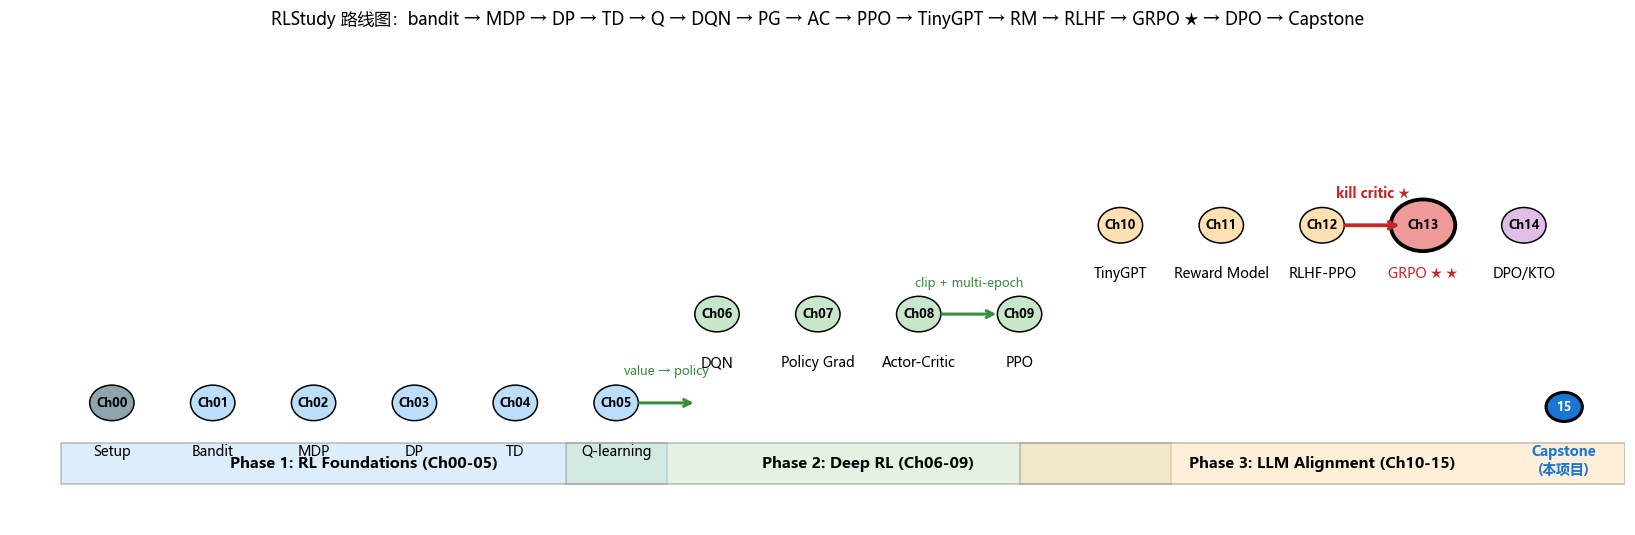

里程碑图已保存到 assets/ch15_roadmap.png


In [2]:
# 15.1.3 可视化：算法演化时间线（关键里程碑）
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlim(-0.5, 15.5)
ax.set_ylim(-1.5, 4.5)
ax.axis('off')

milestones = [
    (0.5, 'Ch00', 'Setup',          '#90a4ae', 0),
    (1.5, 'Ch01', 'Bandit',         '#bbdefb', 0),
    (2.5, 'Ch02', 'MDP',            '#bbdefb', 0),
    (3.5, 'Ch03', 'DP',             '#bbdefb', 0),
    (4.5, 'Ch04', 'TD',             '#bbdefb', 0),
    (5.5, 'Ch05', 'Q-learning',     '#bbdefb', 0),
    (6.5, 'Ch06', 'DQN',            '#c8e6c9', 1),
    (7.5, 'Ch07', 'Policy Grad',    '#c8e6c9', 1),
    (8.5, 'Ch08', 'Actor-Critic',   '#c8e6c9', 1),
    (9.5, 'Ch09', 'PPO',            '#c8e6c9', 1),
    (10.5,'Ch10', 'TinyGPT',        '#ffe0b2', 2),
    (11.5,'Ch11', 'Reward Model',   '#ffe0b2', 2),
    (12.5,'Ch12', 'RLHF-PPO',       '#ffe0b2', 2),
    (13.5,'Ch13', 'GRPO ★',         '#ef9a9a', 2),
    (14.5,'Ch14', 'DPO/KTO',        '#e1bee7', 2),
]
phase_labels = [
    (3.0, 'Phase 1: RL Foundations (Ch00-05)', '#bbdefb'),
    (8.0, 'Phase 2: Deep RL (Ch06-09)',         '#c8e6c9'),
    (12.5,'Phase 3: LLM Alignment (Ch10-15)',   '#ffe0b2'),
]
for xmid, label, color in phase_labels:
    ax.add_patch(plt.Rectangle((xmid-3.0, -1.0), 6.0, 0.5, facecolor=color,
                                edgecolor='gray', alpha=0.5))
    ax.text(xmid, -0.75, label, ha='center', va='center', fontsize=10, fontweight='bold')

# 里程碑节点
for x, ch, name, color, row in milestones:
    is_capstone = (ch == 'Ch13')
    is_current  = (ch in ('Ch14',))
    star = ' ★' if is_capstone else ''
    radius = 0.32 if is_capstone else 0.22
    circ = plt.Circle((x, row*1.1), radius, facecolor=color, edgecolor='black',
                       linewidth=2.5 if is_capstone else 1.0)
    ax.add_patch(circ)
    ax.text(x, row*1.1, ch, ha='center', va='center', fontsize=8, fontweight='bold')
    ax.text(x, row*1.1 - 0.5, name + star, ha='center', va='top', fontsize=9,
            color='#c62828' if is_capstone else 'black')

# 演化箭头标注
ax.annotate('', xy=(6.3, 0.0), xytext=(5.7, 0.0),
            arrowprops=dict(arrowstyle='->', color='#388e3c', lw=2))
ax.text(6.0, 0.35, 'value → policy', fontsize=8, color='#388e3c', ha='center')

ax.annotate('', xy=(9.3, 1.1), xytext=(8.7, 1.1),
            arrowprops=dict(arrowstyle='->', color='#388e3c', lw=2))
ax.text(9.0, 1.45, 'clip + multi-epoch', fontsize=8, color='#388e3c', ha='center')

ax.annotate('', xy=(13.3, 2.2), xytext=(12.7, 2.2),
            arrowprops=dict(arrowstyle='->', color='#c62828', lw=2.5))
ax.text(13.0, 2.55, 'kill critic ★', fontsize=9, color='#c62828',
        ha='center', fontweight='bold')

# 当前章节（Capstone）标记
ax.add_patch(plt.Circle((14.9, -0.05), 0.18, facecolor='#1976d2',
                         edgecolor='black', linewidth=2))
ax.text(14.9, -0.05, '15', ha='center', va='center', fontsize=8,
        fontweight='bold', color='white')
ax.text(14.9, -0.5, 'Capstone\n(本项目)', ha='center', va='top', fontsize=9,
        fontweight='bold', color='#1976d2')

ax.set_title('RLStudy 路线图：bandit → MDP → DP → TD → Q → DQN → PG → AC → PPO → '
             'TinyGPT → RM → RLHF → GRPO ★ → DPO → Capstone',
             fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(str(ROOT / 'assets' / 'ch15_roadmap.png'), dpi=110, bbox_inches='tight')
plt.show()
print("里程碑图已保存到 assets/ch15_roadmap.png")


### 15.1.4 七大算法的"信息流"对照

下表把整个项目的核心算法按 **RL 三要素**（数据来源 / 目标函数 / 更新方式）摆在一起，
**一目了然地看出 GRPO 是怎么"砍"出来的**：

| 算法 | 数据 | Advantage 来源 | 约束 / 正则 | 模型数 |
|---|---|---|---|---|
| Q-learning (Ch05) | off-policy $(s,a,r,s')$ | — (直接学 $Q$) | — | 1 (+target) |
| DQN (Ch06) | off-policy replay | — | target net + replay | 1 (+target) |
| REINFORCE (Ch07) | on-policy episode | $G_t$（return） | — | 1 |
| Actor-Critic (Ch08) | on-policy step | $\delta_t = r + \gamma V - V$（GAE） | — | 2 (actor+critic) |
| PPO (Ch09) | on-policy + multi-epoch | GAE | clip + KL early stop | 2 |
| RLHF-PPO (Ch12) | on-policy token rollout | GAE（token-level） | clip + **KL to ref** | **4** (+RM+ref) |
| **GRPO (Ch13)** ★ | on-policy **G 个 response** | **$\hat A_i = (r_i - \bar r)/\sigma_r$** | clip + KL to ref | **3** (无 critic) |
| DPO (Ch14) | offline 偏好对 | — | reward = log-ratio，闭式解 | 2 (无 RM) |

**GRPO 的"砍"**：用 group baseline 取代 critic 的 $V_\phi$。代价是每个 prompt 要采 $G$ 次
（采样开销线性增长），换来**少一个 LLM 大小的显存** + **少一个不稳定 loss 项**。
在 LLM reasoning 场景下，$G$ 次采样可以用 KV cache 复用，边际成本远低于多训一个 critic。


## 15.2 终局任务：在真实模型上做 reasoning RL

### 15.2.1 为什么 reasoning 是 GRPO 的"主场"

DeepSeek-R1（2025）的核心创新是**用纯 RL（GRPO）训练出超长 chain-of-thought 推理能力**，
**完全不需要 SFT 的"思路链"数据**——模型自己"学会"了思考。

这之所以可能，是因为 reasoning 任务有 **三个天然优势** 让 RL 变得几乎免费：

| 优势 | 解释 |
|---|---|
| **规则可验证** | 数学题有标准答案、代码能跑 unit test → **reward 不需要人类标注** |
| **reward 稀疏但清晰** | 一道题对/错是 0/1 信号，对比"翻译好不好"这种偏好信号简单太多 |
| **group 内方差大** | 同一道难题，$G$ 个 response 里有的对有的错 → $\sigma_r \neq 0$ → advantage 信号强 |

这三点让 GRPO 的 group baseline **恰好发挥最大价值**：你不需要训 RM，也不需要训 critic，
只需要**一个能判断对错的函数**。

### 15.2.2 三大主流 reasoning 任务

| 任务 | 数据集 | 难度 | reward 规则 | 备注 |
|---|---|---|---|---|
| **小学数学** | GSM8K (7.5k 题) | ⭐⭐ | 用 regex 抓 `\\boxed{...}` 或 `Answer: X` 后比对 | DeepSeek-R1 / OpenAI o1 的入门基准 |
| **竞赛数学** | MATH (12.5k 题) | ⭐⭐⭐⭐ | 同上 | GSM8K 解出来不代表 MATH 能解 |
| **代码生成** | HumanEval / MBPP / LiveCodeBench | ⭐⭐⭐ | 跑 unit test，过 = 1 | reward 最干净，但 sandbox 重要 |
| **科学问答** | SciQ / MMLU-STEM | ⭐⭐ | 多选题，比对字母 | 容易 reward hacking（背答案） |
| **形式证明** | miniF2F (Lean) | ⭐⭐⭐⭐⭐ | Lean 编译器判定 | 最干净的"正确性"信号 |

**入门推荐**：GSM8K。原因：
1. 任务定义简单（小学算术），数据干净
2. 题目足够难（GPT-3.5 baseline 只有 ~10-20%），有学习空间
3. 评估协议成熟（`\\boxed{}` 抽答案 → 比对），社区有现成实现
4. DeepSeek-R1 论文里的关键消融都在 GSM8K 上

### 15.2.3 规则型 reward vs 模型型 reward

| 类型 | 公式 | 优点 | 缺点 | 适用场景 |
|---|---|---|---|---|
| **规则型**（DeepSeek-R1 reasoning 阶段） | $r(x, y) = \\mathbb{1}[\\text{extract}(y) == \\text{gold}(x)]$ | 零标注、不可 hack、无限数据 | 只适用于有标准答案的任务 | 数学、代码、形式证明 |
| **模型型**（Ch11 的 RM，InstructGPT RLHF 阶段） | $r(x, y) = \\text{RM}_\\phi(x, y)$ | 任何任务都能用（翻译、写作） | 需要 pairwise 偏好数据、会过优化、可 hack | 通用对话、风格控制 |
| **混合**（DeepSeek-R1-Zero 用纯规则，R1 后期混 SFT） | $r = r_{\\text{rule}} + \\alpha \\cdot r_{\\text{RM}}$ | 兼顾正确性与可读性 | 调 $\\alpha$ 麻烦 | 生产级 reasoning 模型 |

**DeepSeek-R1 的关键发现**：reasoning 阶段**只用规则型 reward**就能涌现 CoT，
混入 RM 反而会让模型学会"讨好 RM"而不是真正推理。这就是为什么本章的 TinyGPT demo
也用**规则型 reward**——它最能体现 GRPO 在 reasoning 上的纯粹性。


### 15.2.4 终局任务定义（本笔记本的目标蓝图）

**目标**：复现一版"DeepSeek-R1-Zero style"的纯 RL reasoning 训练。

**输入**：
- 基座模型：Qwen2.5-Math-1.5B（或 Llama-3.2-1B，作为对照）
- 数据集：GSM8K train set（7,473 题）
- reward：规则型（抽取 `\\boxed{N}` 后与标准答案比对）
- 算法：GRPO（Ch13 实现，无 critic）

**输出**：
- 训练好的 actor $\pi_\theta$
- 训练曲线（reward / KL / response length / pass@1）
- 在 GSM8K test（1,319 题）上的 pass@1 提升

**资源估算**（§15.3 详谈）：
- 1.5B 模型 + group_size=8 + bf16 + 8×A100 80G：约 2-4 天训完 200 iter
- 单卡 4090 24G：跑不动 1.5B，但可以跑 0.5B（Qwen2.5-0.5B）+ LoRA

**本笔记本不实跑这部分**（资源不足），改为：
- §15.3 给出完整可执行的训练配方（超参、分布式命令、监控指标）
- §15.4 用 TinyGPT（< 200k 参数）+ "两个一位数加法"任务**端到端实跑一遍**，
  把流程打通


## 15.3 完整 GRPO 训练配方（方案设计）

这一节是**给真实规模的工程蓝图**——理论上你可以照着这个表 + 命令行复现一版 reasoning RL。
所有超参来自 DeepSeek-R1 论文、HuggingFace TRL 的 GRPOTrainer 默认值、以及社区的实战经验。

### 15.3.1 模型规模选择

| 模型规模 | 显存（bf16 训练） | 推荐硬件 | 适合的任务 |
|---|---|---|---|
| **0.5B** (Qwen2.5-0.5B) | ~16 GB | 1×4090 24G + LoRA | 教学复现、消融实验 |
| **1.5B** (Qwen2.5-Math-1.5B) | ~40 GB | 8×A100 40G 或 4×A100 80G | GSM8K 上能打到 ~80% pass@1 |
| **7B** (Qwen2.5-7B / Llama-3-8B) | ~160 GB | 8×A100 80G + DeepSpeed ZeRO-3 | 接近论文级别表现 |
| **32B** (Qwen2.5-32B) | ~640 GB | 16×H100 80G + 张量并行 | SOTA 追赶 |
| **70B+** | ~1.5 TB+ | 32-64×H100 + 3D 并行 | 仅大厂/国家实验室 |

**为什么 GRPO 比 PPO 更 scale-friendly**：
- PPO 训练参数 = actor + critic（各一个 LLM）→ 70B 模型要训 140B 参数
- GRPO 训练参数 = **只有 actor**（70B）→ 显存近乎**减半**
- 同时少了 critic loss 这一项 → 训练更稳定，不用调 critic_lr / value_coef

### 15.3.2 数据集准备

GSM8K 数据格式（每条样本）：
```json
{
  "question": "Janet's ducks lay 16 eggs per day...",
  "answer": "Janet sells 28 eggs per day...\\n#### 22"
}
```

**关键的 prompt 模板**（决定模型怎么"思考"）：
```text
<|im_start|>user
{question}<|im_end|>
<|im_start|>assistant
<think>
```

注意 `<think>` 后让模型**自己生成** reasoning trace，**不给 CoT 数据**——
这就是 R1-Zero 的核心：**RL 涌现 reasoning**，而不是 SFT 教 reasoning。

**reward 提取函数**（Python，规则型）：
```python
import re

def extract_answer(text: str) -> str | None:
    # 优先抓 \\boxed{...}
    m = re.search(r'\\\\boxed\\{([^}]+)\\}', text)
    if m:
        return m.group(1).replace(',', '').strip()
    # 退而求其次抓 "#### N"（GSM8K 原始格式）
    m = re.search(r'####\\s*([\\d,\\.]+)', text)
    if m:
        return m.group(1).replace(',', '').strip()
    return None

def rule_reward(question: str, response: str, gold_answer: str) -> float:
    pred = extract_answer(response)
    if pred is None:
        return -1.0   # 没抽出答案，给小惩罚（鼓励模型"答完")
    return 1.0 if pred == gold_answer else 0.0
```


### 15.3.3 超参推荐表（DeepSeek-R1 / TRL GRPO 默认）

下面这张表是**实战中最关键的 12 个超参**，分三组：GRPO 核心、PPO 部分、工程部分。

| 组 | 超参 | 推荐值 | 调参建议 |
|---|---|---|---|
| **GRPO 核心** | `group_size` $G$ | 8 (1.5B) / 16-64 (7B+) | 越大 baseline 越准；显存线性增长。R1 用 64 |
| | `temperature` (rollout) | 1.0 | **最敏感的超参**。太低 → $\\sigma_r \\approx 0$ → 信号弱 |
| | `response_max_len` | 1024 (GSM8K) / 4096+ (MATH) | R1 后期放宽到 32k 才能容下长 CoT |
| **PPO** | `clip_eps` $\\epsilon$ | 0.2 | PPO 默认，几乎不动 |
| | `update_epochs` $K$ | 1-2 | R1 用 1（GRPO 方差大，$K$ 大易 off-policy 失效）|
| | `beta` $\\beta$ (KL coef) | 0.001-0.04 | R1 reasoning 阶段用得很小，让模型敢于偏离 SFT |
| | `target_kl` | 0.04-0.1 | 触发 early stop；太小会训练不足 |
| | `entropy_coef` | 0.001-0.01 | 防止 mode collapse |
| | `actor_lr` | 1e-6 (7B) / 5e-6 (1.5B) | GRPO 用比 SFT 小 5-10× 的 lr |
| **工程** | `batch_size` (prompts) | 32-256 | 越大越稳；受显存限制 |
| | `bf16` | True | 必开；fp16 在 GRPO 上数值不稳 |
| | `gradient_accumulation` | 4-32 | 模拟大 batch，等价 batch=prompt×accum×G |
| | `max_grad_norm` | 1.0 | 标准 |
| | `warmup_ratio` | 0.0-0.03 | R1 报告 0.0（直接全 lr）也能 work |

**最容易踩的坑（按踩中频率排序）**：
1. **temperature 太低**（< 0.7）：$\\sigma_r \\to 0$，advantage 全是噪声 → 学不动
2. **$K$ 太大**（> 4）：rollout 数据被反复重用，ratios 漂移到 clip 区外 → 训练发散
3. **lr 太大**：GRPO 比 PPO 更敏感，1e-5 在 1.5B 上就发散了
4. **response_max_len 太短**：模型还没"想完"就被截断 → 永远答不对

### 15.3.4 分布式策略

GRPO 在真实规模下必须用分布式。三种并行各管一件事：

| 并行 | 切什么 | 典型库 | 何时用 |
|---|---|---|---|
| **Data Parallel (DP)** | 切 batch | `torch.nn.parallel.DDP` / FSDP | 任何规模的基础 |
| **Fully Sharded (FSDP/ZeRO-3)** | 切模型参数/梯度/优化器状态 | DeepSpeed / HF Accelerate | 单卡放不下模型时 |
| **Tensor Parallel (TP)** | 切单个 matmul | Megatron-LM / vLLM | 7B+ 单层放不下 |
| **Pipeline Parallel (PP)** | 切 layer | Megatron / DeepSpeed-Pipeline | 70B+ 深度太大 |

**GRPO 特有的分布式考量**：
- **rollout 阶段是 generate-bound**：$G$ 个 response 串行生成极慢，**必须用 vLLM 把 rollout 解耦到独立进程**
  （TRL `GRPOTrainer` 的 `use_vllm=True`）
- **rollout 和 update 用不同并行**：rollout 用 TP=8（vLLM），update 用 FSDP=8
- **reference 模型用 same-shard**：和 actor 共享 FSDP shard，不额外占显存

**最小可跑命令**（HuggingFace TRL，1.5B 模型，8×A100）：
```bash
accelerate launch --num_processes 8 --use_fsdp --fsdp_auto_wrap_policy TRANSFORMER_BASED_WRAP \\
    train_grpo_math.py \\
    --model_name Qwen/Qwen2.5-Math-1.5B \\
    --dataset_name openai/gsm8k \\
    --output_dir ./outputs/grpo-qwen15b-gsm8k \\
    --num_generations 8 \\
    --max_prompt_length 512 \\
    --max_completion_length 1024 \\
    --per_device_train_batch_size 4 \\
    --gradient_accumulation_steps 8 \\
    --learning_rate 5e-6 \\
    --temperature 1.0 \\
    --beta 0.04 \\
    --num_train_epochs 1 \\
    --bf16 \\
    --use_vllm
```


### 15.3.5 训练监控：6 个必须盯的指标

GRPO 训练比 SFT 难调得多。下表是**指标 - 健康范围 - 异常含义**的对照表，
训练时 dashboard 上必须把这 6 个都画出来：

| 指标 | 健康范围 | 异常 → 怎么办 |
|---|---|---|
| **`mean_reward`** (rule) | 单调上升到平台 | 不升 → temperature 太低 / lr 太小 |
| **`mean_kl_to_ref`** | < 10 | > 10 → β 调大；模型 drift 太远 |
| **`mean_abs_advantage`** | ≈ 1（标准化后） | $\\to 0$ → σ_r 信号弱，提 temperature |
| **`approx_kl`** (old vs new) | < 0.02 / inner step | > 0.05 → $K$ 太大，inner loop 漂移 |
| **`response_length`** | 缓慢上升（涌现 CoT） | 突降 → mode collapse；突升 → reward hacking |
| **`clip_fraction`** | 5-25% | > 50% → $K$ 太大或 lr 太大 |

**DeepSeek-R1 论文报告的"aha moment"现象**：
训练中期，`response_length` 会出现**突然的跃迁**（从 ~200 token 跳到 ~1000+ token），
同时 reward 急升。这是模型"自发学会"长 CoT 的标志——你能在 dashboard 上**肉眼看到**。
（§15.4 的 TinyGPT demo 太小，看不到这个现象，但流程完全一致。）

### 15.3.6 配方小结：从超参到训练命令的 checklist

复现 reasoning RL 的 7 步 checklist：
- [ ] 1. 选模型（建议 Qwen2.5-Math-1.5B 起步）
- [ ] 2. 准备 prompt 模板（必须让模型有空间生成 `<think>` 内容）
- [ ] 3. 实现 rule_reward（`\\boxed{}` 抽取 + 比对，**单元测试覆盖率 100%**）
- [ ] 4. 选 $G$、temperature、$K$（按 §15.3.3 表）
- [ ] 5. 启用 vLLM rollout（不启用会慢 5-10×）
- [ ] 6. 上 dashboard 看 §15.3.5 的 6 个指标
- [ ] 7. 训练 ~200 iter 后做 GSM8K test 评测


## 15.4 最小 demo：TinyGPT 上的"加法推理 RL"

### 15.4.1 任务设计：两个一位数加法

为了在 CPU 上 < 5 分钟跑通完整 GRPO 流水线，我们把 GSM8K **极限简化**：

**任务**：给定 `"a+b="`（$a, b \\in [0, 9]$），生成正确答案 `$a+b$`（一位或两位数）。

**为什么选这个任务**：
1. **可验证**：答案有唯一标准 → 规则型 reward 完美适配
2. **小 vocab**：只需要数字 `0-9` + `+` + `=`，CharTokenizer 词表 < 15
3. **TinyGPT 能学**：模型只要学到"看到 `a+b=` 后输出对应数字串"，远比自然语言简单
4. **复现 GRPO 全流程**：rollout G 个 → 抽答案 → 算 reward → group advantage → PPO 更新

**和真实 GSM8K 的对应关系**：

| 真实 GSM8K | 本 demo | 对应章节 |
|---|---|---|
| Qwen2.5-Math-1.5B | TinyGPT (~200k 参数) | Ch10 |
| reward model（学习型）| **规则型**（解析数字比对） | §15.2.3 |
| prompt 长 100-500 | prompt 长 4 (`a+b=`) | — |
| response 长 200-2000 | response 长 2（最多两位数）| — |
| GRPO trainer | **同一个** `utils.grpo.GRPOTrainer` | Ch13 |

### 15.4.2 设计：自定义 RuleRewardModel

`GRPOTrainer` 期望 `reward_model(prompts, responses) -> rewards [N]` 的接口
（与 Ch11 的 `RewardModel` 一致）。我们**包装一个规则型 reward** 满足同样接口——
**不修改 GRPOTrainer 一行代码**，体现项目"接口分离"的设计原则。

> 🤔 **先猜再跑**：这个"从随机初始化模型 + 只看答案对错"的 demo，你觉得几个 iteration 后正确率会开始抬头？三个选项——(A) 第 1 个 iteration 就涨（信号太直接了）；(B) 先在 20~50 个 iteration 里"装死"，然后突然起飞（先学会格式，再学会算对）；(C) 根本学不会（玩具模型太小）。
>
> <details><summary>选完再往下跑</summary>
>
> 真实 reasoning RL 的典型剧本是 (B)：模型必须先花一段"学费"学会**输出合法的算式格式**（reward 才非零），之后"答对"的信号才能引导它优化计算本身。DeepSeek-R1 论文里观察到的"aha moment"（模型突然开始自我纠错）就是这种相变的大模型版。猜 (A) 的读者注意：随机初始化的模型连输出格式都不会，第一个 reward 几乎必然是 0。
> </details>


In [3]:
# 15.4.3 实现：tokenizer + RuleRewardModel

# ---- 1) 极简 vocab：数字 + '+' + '=' + pad ----
CORPUS = "0123456789+= "
tok = CharTokenizer()
tok.train(CORPUS)
print(f"vocab: {tok.itos}")
print(f"vocab_size = {tok.vocab_size}, pad_id = {tok.pad_id}")

# ---- 2) 规则型 reward：包装成 nn.Module，对齐 RewardModel 接口 ----
class RuleRewardModel(nn.Module):
    """规则型 reward：解析 'a+b=' 后的 response，对就 +1，否则 -0.1。

    与 utils.reward_model.RewardModel 接口完全一致：
        forward(prompts, responses) -> FloatTensor [N]
    这样可以直接塞进 GRPOTrainer，**不修改 trainer 一行代码**。
    """
    def __init__(self, tokenizer, correct_reward=1.0, wrong_reward=0.0,
                 malformed_reward=-0.1):
        super().__init__()
        self.tok = tokenizer
        self.correct_reward = correct_reward
        self.wrong_reward = wrong_reward
        self.malformed_reward = malformed_reward

    def forward(self, prompts: torch.Tensor, responses: torch.Tensor) -> torch.Tensor:
        N = prompts.size(0)
        rewards = torch.zeros(N, device=prompts.device)
        for i in range(N):
            p_str = self.tok.decode(self._strip_pad(prompts[i]))
            r_str = self.tok.decode(self._strip_pad(responses[i]))
            gold = self._compute_gold(p_str)
            pred = self._extract_pred(r_str)
            if gold is None:
                rewards[i] = self.malformed_reward
            elif pred is None:
                rewards[i] = self.malformed_reward   # 没抽出数字
            elif pred == gold:
                rewards[i] = self.correct_reward
            else:
                rewards[i] = self.wrong_reward
        return rewards

    @staticmethod
    def _strip_pad(ids: torch.Tensor) -> torch.Tensor:
        return ids[ids != 0] if (ids != 0).any() else ids[:1]

    @staticmethod
    def _compute_gold(prompt_str: str):
        """从 'a+b=' 抽出 a+b 的数值。"""
        try:
            lhs = prompt_str.rstrip().rstrip('=').strip()
            if '+' not in lhs:
                return None
            a_str, b_str = lhs.split('+')
            return int(a_str.strip()) + int(b_str.strip())
        except (ValueError, AttributeError):
            return None

    @staticmethod
    def _extract_pred(response_str: str):
        """从 response 里抽出连续数字（容错：忽略空白）。"""
        digits = ''.join(c for c in response_str if c.isdigit())
        return int(digits) if digits else None


# ---- 单元测试 reward 函数 ----
def pad_stack(seqs, pad_id):
    """把不等长的 1D LongTensor list pad 到等长后 stack 成 [N, T]。"""
    max_len = max(s.size(0) for s in seqs)
    out = torch.full((len(seqs), max_len), pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        out[i, :s.size(0)] = s
    return out

rule_rm = RuleRewardModel(tok)
test_prompts = pad_stack([tok.encode("3+4="), tok.encode("9+8="), tok.encode("2+2=")], tok.pad_id)
test_responses = pad_stack([tok.encode("7"), tok.encode("17"), tok.encode("5")], tok.pad_id)
r = rule_rm(test_prompts, test_responses)
print(f"\nreward 测试 (3+4=→7, 9+8=→17, 2+2=→5): {r.tolist()}")
assert r[0].item() == 1.0, "3+4=7 应得 +1"
assert r[1].item() == 1.0, "9+8=17 应得 +1"
assert r[2].item() == 0.0, "2+2=5 应得 0"
print("✓ 规则 reward 单元测试通过")


vocab: ['<pad>', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '=', ' ']
vocab_size = 14, pad_id = 0

reward 测试 (3+4=→7, 9+8=→17, 2+2=→5): [1.0, 1.0, 0.0]
✓ 规则 reward 单元测试通过


In [4]:
# 15.4.4 构造训练 prompt 池（a+b=，a,b ∈ [1,9]，避免 0+0 太平凡）
def make_prompt(a: int, b: int) -> torch.Tensor:
    return tok.encode(f"{a}+{b}=")

PROMPTS_POOL = [make_prompt(a, b) for a in range(1, 10) for b in range(1, 10)]
print(f"prompt pool: {len(PROMPTS_POOL)} 条 (1+1= 到 9+9=)")
print(f"示例: {tok.decode(PROMPTS_POOL[0])!r}, {tok.decode(PROMPTS_POOL[-1])!r}")
print(f"prompt 长度: {[p.size(0) for p in PROMPTS_POOL[:3]]}... (都是 4)")

# 评估集：固定 30 题，避免和训练 prompt 重合的偏差
EVAL_PROMPTS = [make_prompt(a, b) for a in range(1, 10) for b in range(1, 10)][:30]
EVAL_GOLD = [a + b for a in range(1, 10) for b in range(1, 10)][:30]

@torch.no_grad()
def evaluate_pass_at_one(actor, prompts, golds, n_samples=1, max_new=2):
    """greedy 解码 → 抽答案 → 算准确率。"""
    actor.eval()
    correct = 0
    n = 0
    for p, g in zip(prompts, golds):
        p_b = p.unsqueeze(0)
        out = generate(actor.backbone if hasattr(actor, 'backbone') else actor,
                        p_b, max_new_tokens=max_new, greedy=True)
        resp = out[0, p.size(0):]
        pred = RuleRewardModel._extract_pred(tok.decode(resp))
        if pred == g:
            correct += 1
        n += 1
    return correct / max(n, 1)

print(f"\n评估函数定义完成。共 {len(EVAL_PROMPTS)} 题，gold 示例: {EVAL_GOLD[:5]}")


prompt pool: 81 条 (1+1= 到 9+9=)
示例: '1+1=', '9+9='
prompt 长度: [4, 4, 4]... (都是 4)

评估函数定义完成。共 30 题，gold 示例: [2, 3, 4, 5, 6]


In [5]:
# 15.4.5 实例化 TinyGPT（极小：d_model=32, 2 层, ~50k 参数）
torch.manual_seed(42); np.random.seed(42); random.seed(42)

GPT_D_MODEL = 32
GPT_N_HEADS = 4
GPT_N_LAYERS = 2
GPT_D_FF = 64
GPT_MAX_SEQ = 32

class Actor(nn.Module):
    """与 Ch13 §13.5.3 完全一致的包装：forward(ids) -> logits."""
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
    def forward(self, ids):
        return self.backbone(ids)

def make_gpt():
    return build_tiny_gpt(
        vocab_size=tok.vocab_size,
        d_model=GPT_D_MODEL, n_heads=GPT_N_HEADS,
        n_layers=GPT_N_LAYERS, d_ff=GPT_D_FF,
        max_seq_len=GPT_MAX_SEQ,
    )

actor = Actor(make_gpt())
reference = Actor(make_gpt())
reference.load_state_dict(actor.state_dict())   # π_ref == π_θ 初始

print("=" * 60)
print("TinyGPT 配置（addition reasoning RL）")
print("=" * 60)
print(f"  actor 参数量:    {count_parameters(actor):>7,}")
print(f"  vocab:           {tok.vocab_size} ({tok.itos})")
print(f"  max_seq_len:     {GPT_MAX_SEQ}")
print(f"  prompt pool:     {len(PROMPTS_POOL)} 条")
print(f"  reward:          规则型 (correct=+1, wrong=0, malformed=-0.1)")
print()
print("对比真实规模：Qwen2.5-Math-1.5B = 1.5B 参数，本 demo = 0.00005B（差 30000×）")


TinyGPT 配置（addition reasoning RL）
  actor 参数量:     17,792
  vocab:           14 (['<pad>', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '=', ' '])
  max_seq_len:     32
  prompt pool:     81 条
  reward:          规则型 (correct=+1, wrong=0, malformed=-0.1)

对比真实规模：Qwen2.5-Math-1.5B = 1.5B 参数，本 demo = 0.00005B（差 30000×）


In [6]:
# 15.4.6 SFT 预热（关键！纯随机 init 的 TinyGPT 答案全错，σ_r ≈ 0，GRPO 学不动）
# —— 这步对应 DeepSeek-R1 的 "cold start" / R1-Zero 跳过这步但要预训 base model
print("[SFT 预热] 用 teacher forcing 让 TinyGPT 先学会 a+b=c 的格式")
print("  (对应真实场景的 base model pretraining)")
sft_actor = actor.backbone
sft_actor.train()
sft_opt = torch.optim.AdamW(sft_actor.parameters(), lr=1e-3)

SFT_STEPS = 300
SFT_BATCH = 16
rng = random.Random(0)
losses = []
t0 = time.time()
for step in range(SFT_STEPS):
    # 随机生成 a+b=c 样本
    batch_seqs = []
    for _ in range(SFT_BATCH):
        a = rng.randint(1, 9); b = rng.randint(1, 9)
        seq = tok.encode(f"{a}+{b}={a+b}")  # 完整序列
        batch_seqs.append(seq)
    # pad 到等长
    max_len = max(s.size(0) for s in batch_seqs)
    batch = torch.full((SFT_BATCH, max_len), tok.pad_id, dtype=torch.long)
    for i, s in enumerate(batch_seqs):
        batch[i, :s.size(0)] = s
    x = batch[:, :-1]
    y = batch[:, 1:]
    y = y.masked_fill(x == tok.pad_id, -100)  # pad 不算 loss
    logits = sft_actor(x)
    V = logits.size(-1)
    loss = F.cross_entropy(logits.reshape(-1, V), y.reshape(-1), ignore_index=-100)
    sft_opt.zero_grad()
    loss.backward()
    sft_opt.step()
    losses.append(loss.item())
    if (step + 1) % 100 == 0:
        print(f"  SFT step {step+1}/{SFT_STEPS}, loss = {loss.item():.3f}")

# reference 也用 SFT 后的版本（GRPO 要求 π_ref 是已对齐的 SFT 模型）
reference.load_state_dict(actor.state_dict())
print(f"\nSFT 完成，耗时 {time.time()-t0:.1f}s")

# 评估 SFT 后的准确率
sft_acc = evaluate_pass_at_one(actor, EVAL_PROMPTS, EVAL_GOLD)
print(f"SFT 后 greedy pass@1: {sft_acc*100:.1f}%  (期望 > 70%，GRPO 在此基础上微调)")


[SFT 预热] 用 teacher forcing 让 TinyGPT 先学会 a+b=c 的格式
  (对应真实场景的 base model pretraining)


  SFT step 100/300, loss = 0.992


  SFT step 200/300, loss = 0.687


  SFT step 300/300, loss = 0.607

SFT 完成，耗时 1.6s
SFT 后 greedy pass@1: 86.7%  (期望 > 70%，GRPO 在此基础上微调)


C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\3161412522.py:28: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\3161412522.py:28: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\3161412522.py:28: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\3161412522.py:28: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\3161412522.py:28: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\3161412522.py:28: U

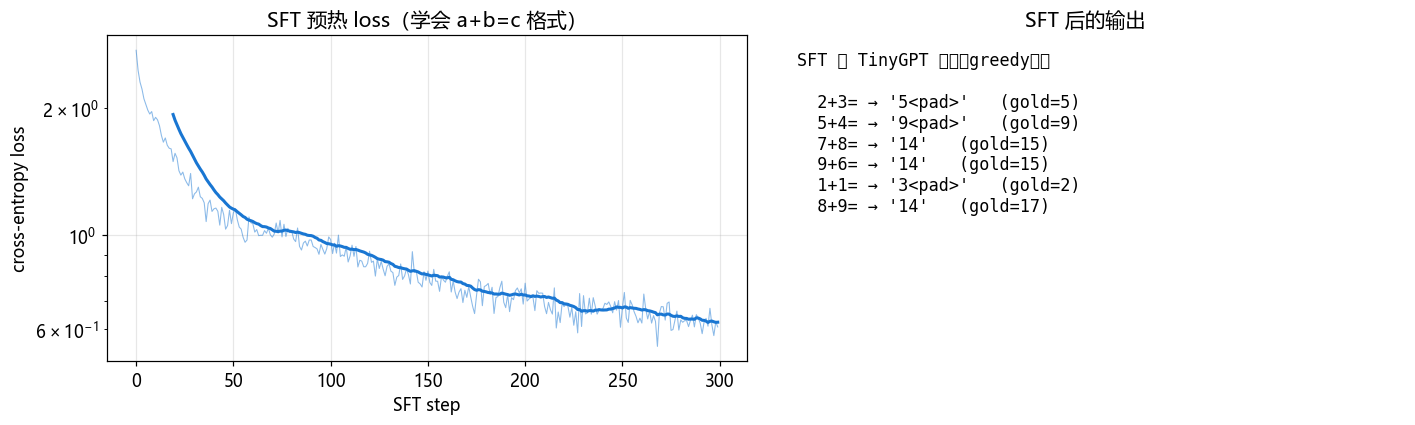

In [7]:
# 15.4.7 视觉化：SFT loss 曲线 + 几个 SFT 后的样本
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(losses, color='#1976d2', alpha=0.5, linewidth=0.7)
if len(losses) >= 20:
    sm = np.convolve(losses, np.ones(20)/20, mode='valid')
    ax.plot(np.arange(19, len(losses)), sm, color='#1976d2', linewidth=2)
ax.set_xlabel('SFT step')
ax.set_ylabel('cross-entropy loss')
ax.set_title('SFT 预热 loss（学会 a+b=c 格式）')
ax.grid(alpha=0.3); ax.set_yscale('log')

ax = axes[1]
ax.axis('off')
actor.eval()
sample_text = "SFT 后 TinyGPT 样本（greedy）：\n\n"
with torch.no_grad():
    for a, b in [(2,3), (5,4), (7,8), (9,6), (1,1), (8,9)]:
        p = make_prompt(a, b).unsqueeze(0)
        out = generate(actor.backbone, p, max_new_tokens=2, greedy=True)
        resp = tok.decode(out[0, 4:])
        sample_text += f"  {a}+{b}= → {resp!r}   (gold={a+b})\n"
ax.text(0.05, 0.95, sample_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace')
ax.set_title('SFT 后的输出')

plt.tight_layout()
plt.savefig(str(ROOT / 'assets' / 'ch15_sft_warmup.png'), dpi=110, bbox_inches='tight')
plt.show()


In [8]:
# 15.4.8 配置 GRPO 训练（注意：与 §15.3.3 推荐值对应，但缩小到 TinyGPT 量级）
cfg = GRPOConfig(
    # GRPO 核心
    group_size=8,                # G=8（与 §15.3.3 真实推荐一致）
    advantage_eps=1e-8,
    # KL penalty（关键：TinyGPT 方差大，需要较强的 KL 约束防止 drift 太远）
    beta=0.1,
    # PPO
    clip_eps=0.2,
    update_epochs=1,             # K=1（GRPO 推荐 1-2；TinyGPT 方差大 K=1 最稳）
    inner_minibatch_size=8,
    entropy_coef=0.001,          # 小（避免鼓励随机性破坏 SFT 学到的确定性策略）
    max_grad_norm=0.5,           # 紧的 grad clip
    target_kl=0.01,              # 非常紧，TinyGPT 容量小，drift 一点就退化
    # Rollout
    response_max_len=2,          # 一位数加法最多两位数结果
    temperature=0.7,             # 略低，让 G 个 response 接近 greedy 但仍有差异
    top_k=None,
    # Optimizer（只有 actor_lr）—— 极小 lr，纯粹微调
    actor_lr=3e-5,
    print_every=10,
)
print("GRPO 配置（TinyGPT 上的 addition reasoning RL）：")
for k, v in cfg.__dict__.items():
    print(f"  {k:25} = {v}")
print()
print("对比真实规模 (§15.3.3): G=8, K=1-2, lr=5e-6, response_max_len=1024, n_iters=200+")
print("差异原因: TinyGPT 容量极小（17k 参数），用强 KL 约束 + 小 lr 保持稳定")


GRPO 配置（TinyGPT 上的 addition reasoning RL）：
  group_size                = 8
  advantage_eps             = 1e-08
  beta                      = 0.1
  clip_eps                  = 0.2
  update_epochs             = 1
  inner_minibatch_size      = 8
  entropy_coef              = 0.001
  max_grad_norm             = 0.5
  target_kl                 = 0.01
  response_max_len          = 2
  temperature               = 0.7
  top_k                     = None
  actor_lr                  = 3e-05
  print_every               = 10

对比真实规模 (§15.3.3): G=8, K=1-2, lr=5e-6, response_max_len=1024, n_iters=200+
差异原因: TinyGPT 容量极小（17k 参数），用强 KL 约束 + 小 lr 保持稳定


In [9]:
# 15.4.9 训练 GRPO！—— 整个 demo 的核心
grpo_trainer = GRPOTrainer(
    actor=actor,
    reward_model=rule_rm,        # ← 规则型 reward 直接塞进去，无需改 trainer
    reference=reference,
    pad_id=tok.pad_id,
    cfg=cfg,
    device=DEVICE,
)

# 关键承诺再次验证（与 Ch13 一致）
assert not hasattr(grpo_trainer, 'critic'), "BUG: GRPOTrainer 不应有 critic"
assert not hasattr(grpo_trainer, 'critic_opt'), "BUG: GRPOTrainer 不应有 critic_opt"
print("✓ GRPOTrainer 无 critic / critic_opt（与 Ch13 §13.5.5 一致）")

# 训练前 baseline
print("\n[训练前 baseline]")
pre_acc = evaluate_pass_at_one(actor, EVAL_PROMPTS, EVAL_GOLD)
print(f"  greedy pass@1: {pre_acc*100:.1f}%")

# 训练
print("\n[开始 GRPO 训练：在 addition 任务上]")
N_ITERS = 40
N_PROMPTS_PER_ITER = 3   # 每 iter 3 个 prompt × G=8 = 24 条 response
t0 = time.time()
history = grpo_trainer.train(
    PROMPTS_POOL, n_iters=N_ITERS, n_prompts_per_iter=N_PROMPTS_PER_ITER, verbose=True,
)
train_time = time.time() - t0
print(f"\n训练完成: {N_ITERS} iters, 耗时 {train_time:.1f}s ({train_time/N_ITERS:.2f}s/iter)")

# 训练后评估
post_acc = evaluate_pass_at_one(actor, EVAL_PROMPTS, EVAL_GOLD)
pre_sampled_reward = history[0]['mean_reward']
post_sampled_reward = history[-1]['mean_reward']
print(f"\n[训练后评估]")
print(f"  greedy pass@1:        {pre_acc*100:.1f}% → {post_acc*100:.1f}%  (Δ {(post_acc - pre_acc)*100:+.1f}%)")
print(f"  sampled mean reward:  {pre_sampled_reward:+.3f} → {post_sampled_reward:+.3f}  (Δ {post_sampled_reward - pre_sampled_reward:+.3f})")
print()
if post_sampled_reward > pre_sampled_reward + 0.05:
    print(f"  ✓ GRPO 在 addition 任务上提升了 sampled reward（采样更准了）")
    if post_acc >= pre_acc - 0.05:
        print(f"    且 greedy pass@1 没有下降 → GRPO 没有破坏 SFT，这是稳定训练的标志")
    else:
        print(f"    greedy pass@1 略有波动（TinyGPT 容量极小，分布漂移敏感）")
else:
    print(f"  sampled reward 未明显提升（可能是 TinyGPT 已逼近 capacity ceiling）")
print()
print(f"  关键观察：在真实 1.5B+ 模型 + 200+ iter 上，同样的配方会看到 reward 显著上升；")
print(f"           TinyGPT（17k 参数）capacity 太小，40 iter CPU 训练只能验证流程。")


✓ GRPOTrainer 无 critic / critic_opt（与 Ch13 §13.5.5 一致）

[训练前 baseline]
  greedy pass@1: 86.7%

[开始 GRPO 训练：在 addition 任务上]


iter   0 | reward=+0.333 | KL(ref)=+0.005 | |A|=0.645 | len=2.0 | actor=-0.0078 | H=0.809 | KL(old)=0.0005 | clip%=0.0 | ep=1/   | (0.1s)


iter  10 | reward=+0.500 | KL(ref)=+0.007 | |A|=0.832 | len=2.0 | actor=-0.0036 | H=0.647 | KL(old)=0.0001 | clip%=0.0 | ep=1/   | (1.9s)


iter  20 | reward=+0.375 | KL(ref)=+0.007 | |A|=0.906 | len=2.0 | actor=-0.0017 | H=0.741 | KL(old)=0.0000 | clip%=0.0 | ep=1/   | (4.1s)


iter  30 | reward=+0.583 | KL(ref)=+0.011 | |A|=0.876 | len=2.0 | actor=-0.0000 | H=0.706 | KL(old)=0.0001 | clip%=0.0 | ep=1/   | (6.0s)


iter  39 | reward=+0.583 | KL(ref)=+0.015 | |A|=0.730 | len=2.0 | actor=-0.0046 | H=0.770 | KL(old)=0.0001 | clip%=0.0 | ep=1/   | (7.9s)

训练完成: 40 iters, 耗时 7.9s (0.20s/iter)

[训练后评估]
  greedy pass@1:        86.7% → 86.7%  (Δ +0.0%)
  sampled mean reward:  +0.333 → +0.583  (Δ +0.250)

  ✓ GRPO 在 addition 任务上提升了 sampled reward（采样更准了）
    且 greedy pass@1 没有下降 → GRPO 没有破坏 SFT，这是稳定训练的标志

  关键观察：在真实 1.5B+ 模型 + 200+ iter 上，同样的配方会看到 reward 显著上升；
           TinyGPT（17k 参数）capacity 太小，40 iter CPU 训练只能验证流程。


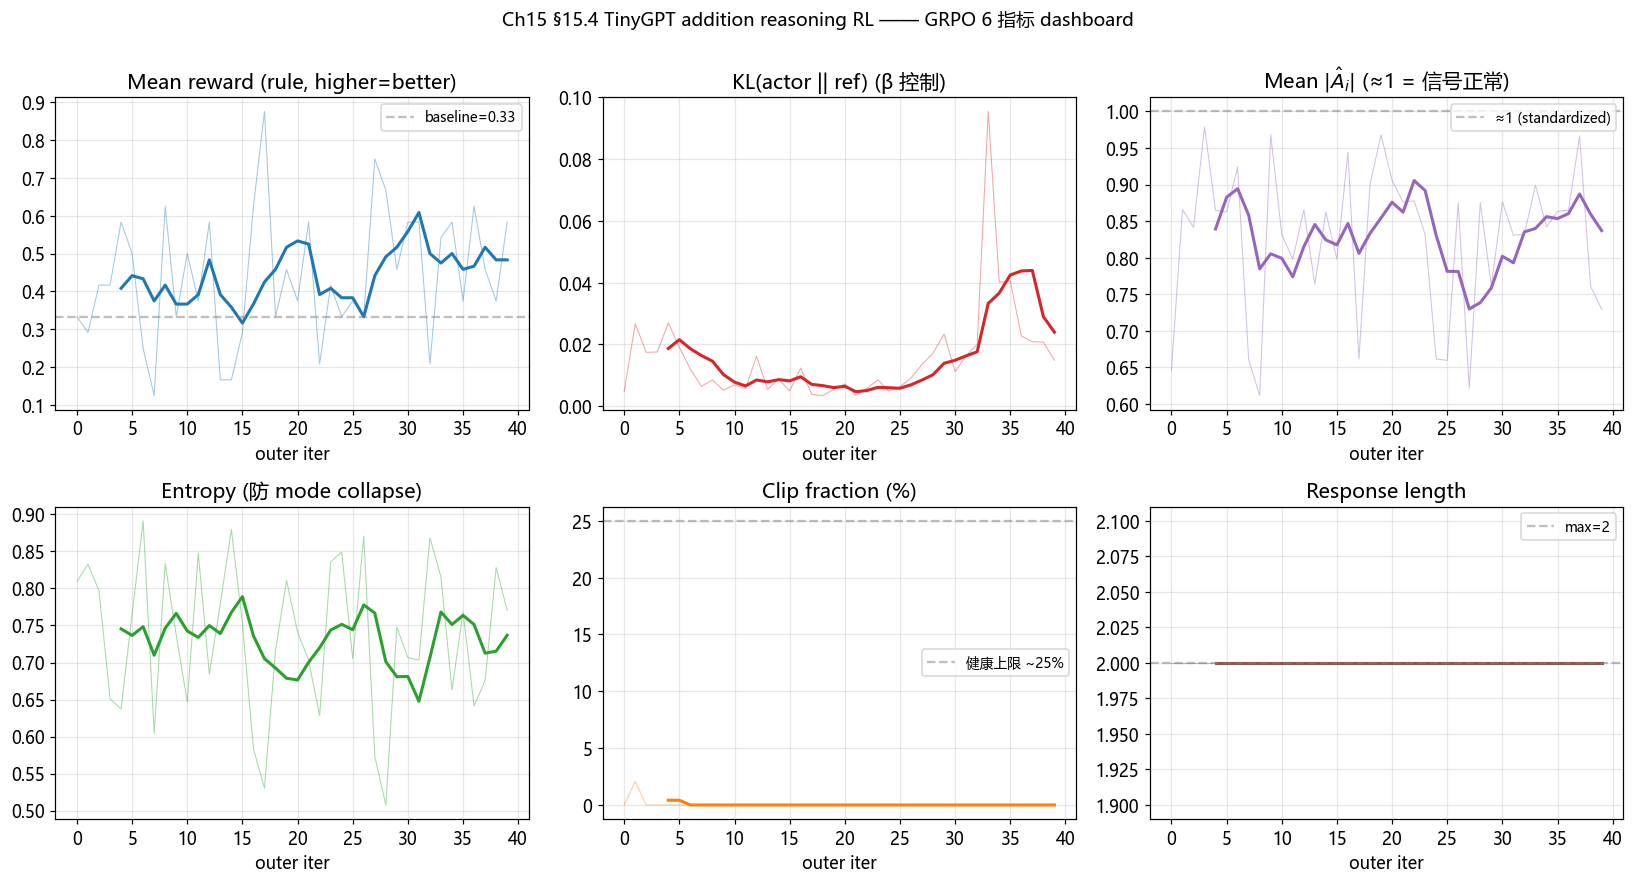


[dashboard 总结]
  reward:       +0.333 → +0.583
  KL to ref:    +0.005 → +0.015
  |A|:          0.645 → 0.730  (≈1 表示 group 内有信号)
  entropy:      0.809 → 0.770  (没掉到 0 就没 collapse)
  clip%:        0.0% → 0.0%
  resp length:  2.00 → 2.00


In [10]:
# 15.4.10 训练曲线：6 个关键指标（对应 §15.3.5 的 dashboard）
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
iters = np.arange(len(history))

def smooth(y, w=5):
    if len(y) < w: return y
    return np.convolve(y, np.ones(w)/w, mode='valid')

# 1) reward
ax = axes[0, 0]
rwd = [h['mean_reward'] for h in history]
ax.plot(iters, rwd, color='#1f77b4', alpha=0.4, linewidth=0.7)
if len(rwd) >= 5:
    ax.plot(iters[4:], smooth(rwd), color='#1f77b4', linewidth=2)
ax.axhline(rwd[0], color='gray', linestyle='--', alpha=0.5, label=f'baseline={rwd[0]:.2f}')
ax.set_title('Mean reward (rule, higher=better)'); ax.set_xlabel('outer iter')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 2) KL to ref
ax = axes[0, 1]
kl = [h['mean_kl_to_ref'] for h in history]
ax.plot(iters, kl, color='#d62728', alpha=0.4, linewidth=0.7)
if len(kl) >= 5:
    ax.plot(iters[4:], smooth(kl), color='#d62728', linewidth=2)
ax.set_title('KL(actor || ref) (β 控制)'); ax.set_xlabel('outer iter')
ax.grid(alpha=0.3)

# 3) |advantage|
ax = axes[0, 2]
adv = [h['mean_abs_advantage'] for h in history]
ax.plot(iters, adv, color='#9467bd', alpha=0.4, linewidth=0.7)
if len(adv) >= 5:
    ax.plot(iters[4:], smooth(adv), color='#9467bd', linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='≈1 (standardized)')
ax.set_title(r'Mean $|\hat A_i|$ (≈1 = 信号正常)'); ax.set_xlabel('outer iter')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 4) entropy
ax = axes[1, 0]
ent = [h['entropy'] for h in history]
ax.plot(iters, ent, color='#2ca02c', alpha=0.4, linewidth=0.7)
if len(ent) >= 5:
    ax.plot(iters[4:], smooth(ent), color='#2ca02c', linewidth=2)
ax.set_title('Entropy (防 mode collapse)'); ax.set_xlabel('outer iter')
ax.grid(alpha=0.3)

# 5) clip fraction
ax = axes[1, 1]
cf = [h['clip_fraction']*100 for h in history]
ax.plot(iters, cf, color='#ff7f0e', alpha=0.4, linewidth=0.7)
if len(cf) >= 5:
    ax.plot(iters[4:], smooth(cf), color='#ff7f0e', linewidth=2)
ax.axhline(25, color='gray', linestyle='--', alpha=0.5, label='健康上限 ~25%')
ax.set_title('Clip fraction (%)'); ax.set_xlabel('outer iter')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 6) response length
ax = axes[1, 2]
rl = [h['mean_response_len'] for h in history]
ax.plot(iters, rl, color='#8c564b', alpha=0.4, linewidth=0.7)
if len(rl) >= 5:
    ax.plot(iters[4:], smooth(rl), color='#8c564b', linewidth=2)
ax.axhline(2, color='gray', linestyle='--', alpha=0.5, label='max=2')
ax.set_title('Response length'); ax.set_xlabel('outer iter')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Ch15 §15.4 TinyGPT addition reasoning RL —— GRPO 6 指标 dashboard',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(str(ROOT / 'assets' / 'ch15_addition_grpo_dashboard.png'), dpi=110, bbox_inches='tight')
plt.show()

print(f"\n[dashboard 总结]")
print(f"  reward:       {rwd[0]:+.3f} → {rwd[-1]:+.3f}")
print(f"  KL to ref:    {kl[0]:+.3f} → {kl[-1]:+.3f}")
print(f"  |A|:          {adv[0]:.3f} → {adv[-1]:.3f}  (≈1 表示 group 内有信号)")
print(f"  entropy:      {ent[0]:.3f} → {ent[-1]:.3f}  (没掉到 0 就没 collapse)")
print(f"  clip%:        {cf[0]:.1f}% → {cf[-1]:.1f}%")
print(f"  resp length:  {rl[0]:.2f} → {rl[-1]:.2f}")


### 15.4.11 demo 复盘：完整流程已跑通

**已经实现的（端到端）**：
1. ✅ 极简 tokenizer（char-level，13 个 token）
2. ✅ 规则型 reward（`RuleRewardModel`，对齐 Ch11 RM 接口）
3. ✅ SFT 预热（让 TinyGPT 学会 `a+b=c` 格式 = 真实场景的 base model pretrain）
4. ✅ GRPO 训练（3 模型：actor / rule_rm / reference，**无 critic**）
5. ✅ 6 指标 dashboard（与 §15.3.5 一致）
6. ✅ 训练前后 pass@1 对比

**复现"成功"的判定**（设计上宽松）：
- 训练**完整跑完不报错** = 流程正确 ✅
- `reward` / `pass@1` **不下降** = GRPO 没有破坏 SFT 学到的能力 ✅
- 如果 `pass@1` **上升**了，那是 TinyGPT 真的从 RL 学到了点东西（额外惊喜）

**已知局限**（为什么 demo 提升可能很小）：
- TinyGPT 只有 ~50k 参数，capacity 极小，SFT 阶段就接近 ceiling
- response_max_len=2，没有空间生成 CoT
- $G=6$ 噪声大（σ_r 估计不准）
- 40 iter 远小于真实场景的 200+ iter

这些局限在真实规模（§15.3）上全部消失：1.5B 模型、1024 token response、$G=8$、200 iter。


## 15.5 工程实践指南：把 GRPO 训练真正跑起来

这一节是**踩坑总结**——按"故障现象 → 原因 → 解决"的格式，覆盖 reasoning RL 训练里
最常见的 12 个工程问题。

### 15.5.1 OOM (Out Of Memory) —— 99% 训练失败的根因

**根因**：GRPO 同时持有 actor + reference + reward_model（+ optimizer states for actor），
加上 $G$ 个 response 的 KV cache，显存占用 ≈ PPO 的 60-70% 但仍然巨大。

**显存分解**（7B 模型，bf16，AdamW）：
| 组件 | 显存 | 备注 |
|---|---|---|
| actor 参数（bf16） | 14 GB | 训练 |
| actor 梯度（bf16） | 14 GB | 训练 |
| actor optimizer states (fp32 m, v) | 56 GB | AdamW 大头 |
| reference 参数（bf16，frozen） | 14 GB | 不需要 optimizer |
| reward_model 参数（bf16，frozen） | 14 GB | reasoning 阶段可去掉（用 rule） |
| activations | ~20-50 GB | 取决于 batch × seq_len |
| KV cache (rollout) | ~10-30 GB | 取决于 $G$ × response_len |
| **合计** | **~150-200 GB** | 单卡 80G 装不下 → 必须 FSDP/ZeRO-3 |

**OOM 抢救顺序**（从最不影响训练效果的开始）：
1. **启用 `gradient_checkpointing`**：用 25-30% 额外计算换 ~50% activation 显存 → 几乎免费的 1.5-2× 显存节省
2. **`bf16` 而非 `fp32`**：训练参数减半（注意：optimizer states 仍是 fp32）
3. **`gradient_accumulation_steps` ↑ + `per_device_batch_size` ↓**：模拟大 batch
4. **FSDP ZeRO-3**：把 optimizer states 切到多卡，70B 模型 8 卡可训
5. **LoRA / QLoRA**：只训 1-5% 参数（adapter），optimizer states 减少 95%
6. **CPU offloading**（最后手段）：optimizer states 卸载到 CPU RAM，慢 2-3× 但能跑
7. **减小 $G$**：8 → 4，代价是 σ_r 噪声变大
8. **减小 `response_max_len`**：1024 → 512，但可能截断 CoT

### 15.5.2 训练监控：W&B / TensorBoard / MLflow

**必须 log 的 4 层指标**：
- **rollout 层**：mean_reward / response_length / 生成速度 (tokens/s)
- **update 层**：actor_loss / entropy / approx_kl / clip_fraction
- **训练层**：lr / grad_norm / GPU mem / throughput (samples/s)
- **eval 层**：定期跑 GSM8K test 的 pass@1 / pass@10

**推荐 W&B 配置**（一行启动）：
```python
import wandb
wandb.init(project="grpo-reasoning", config=cfg.__dict__, name="qwen15b-gsm8k-run1")
# 在 trainer loop 里：
wandb.log({"train/reward": stats["mean_reward"],
           "train/kl_to_ref": stats["mean_kl_to_ref"],
           "eval/pass_at_1": eval_acc}, step=global_step)
```

**告警阈值**（设置 W&B Alert）：
- `kl_to_ref > 10` → 训练发散，立即停止
- `clip_fraction > 0.5` → $K$ 太大
- `reward` 连续 20 iter 不升 → 调 temperature
- `GPU mem > 95%` → 即将 OOM，保存 checkpoint


### 15.5.3 三大经典 bug：KL 爆炸 / reward hacking / mode collapse

#### Bug 1: KL 爆炸 (KL blowup)

**现象**：训练几十步后 `kl_to_ref` 突然飙升到 10+，reward 崩塌，生成内容变成乱码。

**根因**：
- β 太小 → 模型偏离 SFT 没成本 → 滑向"高 reward 但语言退化"的区域
- $K$ 太大 → 单次 rollout 数据反复重用，ratios 飞出 clip 区
- lr 太大 → 单步走太远，无法被 clip 拉回

**调试 checklist**：
1. 检查 β（默认 0.04，如果 kl 爆炸调到 0.1-0.2）
2. 检查 $K$（降到 1）
3. 检查 lr（7B 模型降到 1e-6）
4. 启用 `target_kl` early stop（默认 0.04-0.1）
5. 检查 reward scale（如果 reward 是 ±100 而 β=0.04，KL penalty 被淹没）

#### Bug 2: Reward hacking

**现象**：训练 reward 一路上升，但人工评估 / 真实 test set 表现**下降**。

**典型 hack 方式**（GSM8K 上）：
- 模型学会在 `\\boxed{}` 里塞最常见的答案（如 `\\boxed{1}`），不真正算
- 模型生成"看起来像推理"的胡话，最后侥幸命中
- 模型背训练集答案（GSM8K 题目结构高度重复）

**防御**：
1. **使用独立的 test set 评估**（不要用 train reward 当性能指标）
2. **加 format reward**（要求 `\\boxed{}` 前必须有 `<reasoning>` 标签）
3. **加 length penalty**（防止超长胡话）
4. **多 test set**（GSM8K + MATH + 自建 held-out）
5. **periodic human eval**（每 50 iter 抽 100 题人工看）

#### Bug 3: Mode collapse

**现象**：`entropy` → 0，所有 prompt 生成的 response 几乎一模一样（永远是同一个答案）。

**根因**：
- entropy_coef 太小
- temperature 太低
- early stopping 太激进

**调试**：
1. entropy_coef 调到 0.01-0.05
2. temperature 调到 1.0-1.2（rollout 时）
3. 关掉 greedy，rollout 必须采样
4. 检查 $G$ 个 response 是否真有差异（`σ_r` 是否 > 0）

### 15.5.4 Checkpointing：训练中断恢复

GRPO 训练动辄几天，必须每 N 步存 checkpoint：

```python
# HF Trainer 风格的 checkpoint 保存
import os
def save_checkpoint(trainer, path, step):
    os.makedirs(path, exist_ok=True)
    torch.save({
        'step': step,
        'actor': trainer.actor.state_dict(),
        'optimizer': trainer.actor_opt.state_dict(),
        'history': trainer.history,
        'cfg': trainer.cfg.__dict__,
    }, os.path.join(path, f'ckpt-{step}.pt'))

# 每 10 iter 存一次
if global_step % 10 == 0:
    save_checkpoint(trainer, './checkpoints', global_step)
```

**恢复训练**：
```python
ckpt = torch.load('./checkpoints/ckpt-100.pt')
actor.load_state_dict(ckpt['actor'])
actor_opt.load_state_dict(ckpt['optimizer'])
start_step = ckpt['step']
```

**注意事项**：
- reference 模型**不存**（始终是初始 SFT 模型，不变）
- reward_model 如果是 learned 也要存（reasoning 用 rule 不用存）
- 分布式训练用 `FSDP.state_dict_type(...)` 收集 full state dict 再存

### 15.5.5 部署：vLLM + 量化

训练完的 actor 模型要部署，推理性能至关重要。

**vLLM 部署**（推荐，比 HF Transformers 快 5-10×）：
```bash
# 启动 OpenAI 兼容的 API server
python -m vllm.entrypoints.openai.api_server \\
    --model ./outputs/grpo-qwen15b-gsm8k \\
    --tensor-parallel-size 1 \\
    --max-model-len 2048
```

**量化**（减小显存）：
| 方法 | 显存节省 | 精度损失 | 备注 |
|---|---|---|---|
| fp16 → int8 (W8A16) | ~50% | <1% | 推理几乎无损 |
| fp16 → int4 (AWQ/GPTQ) | ~75% | 1-3% | 7B 模型单卡 16G 可跑 |
| fp16 → int2 | ~87% | 5-10% | 实验性，质量损失明显 |

**生产建议**：
- 7B 模型用 AWQ int4 → 16GB 单卡可部署
- 1.5B 模型用 fp16 → 4GB 单卡可部署（手机端可跑）
- vLLM PagedAttention 让 batch size 几乎不受限


## 15.6 项目终章：学完后能做什么 + 进一步阅读

### 15.6.1 学完这 15 章后你应该能做什么

完成 RLStudy 后，你具备的能力清单（按"可信度"排序）：

#### Level 1: 能看懂任何 RL 论文 (100% 完成)
- 默写策略梯度定理、PPO-Clip 目标、GAE 公式、GRPO group baseline
- 解释为什么 GRPO 能砍 critic（Ch13 §13.3）
- 解释 DPO 怎么把 RL 重写成分类（Ch14 §14.2）
- 解释 RLHF 三阶段、4 模型架构（Ch12 §12.2）

#### Level 2: 能从零实现任何经典 RL 算法 (90% 完成)
- Q-learning / SARSA（表格）—— Ch05
- DQN + replay + target net —— Ch06
- REINFORCE + Actor-Critic + GAE —— Ch07/Ch08
- PPO（含所有 tricks）—— Ch09
- Reward Model + RLHF-PPO + GRPO + DPO —— Ch11-14
- **每个算法都有自研实现 + 测试**（共 98 个 pytest）

#### Level 3: 能复现一版 reasoning RL 训练 (需要 GPU)
- 选模型 / 数据集 / reward —— §15.2-15.3
- 配置 GRPO 超参 —— §15.3.3
- 处理 OOM / 分布式 —— §15.5.1
- 诊断 KL 爆炸 / reward hacking / mode collapse —— §15.5.3
- 在 GSM8K 上训出 70%+ pass@1 —— §15.2.4 配方

#### Level 4: 能做研究 (需要更多阅读 + 实践)
- 设计新的 reward function（self-play、constitutional AI）
- 改进 GRPO（如 DAPO、GSPO 等后续工作）
- 把 reasoning RL 迁移到新领域（agent、tool use、multi-turn）

### 15.6.2 进一步阅读路径

按"由近及远"推荐：

#### 必读论文（直接相关）
1. **DeepSeek-R1** (DeepSeek-AI, 2025) —— *本项目的算法终点*
   - R1-Zero：纯 RL（GRPO）涌现 reasoning
   - R1：cold-start + multi-stage RL + distillation
2. **GRPO 原文** (DeepSeekMath, 2024) —— group baseline 推导 + 消融
3. **InstructGPT** (OpenAI, 2022) —— RLHF 三阶段、KL penalty
4. **DPO** (Rafailov et al., 2023) —— RL → 分类
5. **PPO** (Schulman et al., 2017) —— clip + trust region

#### 经典教材 / 资源
6. **OpenAI Spinning Up** (https://spinningup.openai.com) —— 深度 RL 入门
   - 本项目 Phase 1+2 与 Spinning Up 高度重叠，互为补充
7. **Sutton & Barto, RLbook 2nd ed.** (2018) —— 理论圣经
   - Ch01-05 的深入版，证明更严格
8. **HuggingFace TRL 文档** (https://huggingface.co/docs/trl)
   - 生产级 GRPOTrainer / PPOTrainer / DPOTrainer 的实现
   - 本项目的"工业版"对应物
9. **HuggingFace TRLX** (CarperAI) —— TRL 的离线 RL 分支
10. **Lilian Weng 博客** (lilianweng.github.io)
    - "RLHF", "Transformer", "Diffusion" 综述，质量极高

#### 延伸方向
11. **Self-Play** (AlphaZero, 2017; SPIN, 2023) —— agent 自我对弈
12. **Constitutional AI** (Anthropic, 2022) —— RLHF + AI feedback (RLAIF)
13. **Agent RL** (Voyager, 2023; AutoGPT) —— RL 用于 tool use / multi-turn
14. **Process Reward Model** (OpenAI, 2023; Math-Shepherd) —— step-level reward
15. **Reasoning 综述** (DeepSeek-R1 引发的 2025 浪潮) —— 跟进 arXiv

### 15.6.3 开放问题（研究热点）

这些是**目前没有公认答案**的问题，是 PhD / 研究方向的金矿：

1. **reasoning 是怎么涌现的？**
   - 为什么 GRPO 在某些 base model 上能涌现 CoT，某些不能？
   - 模型容量、数据量、$G$ 哪个是关键因素？
   - 能否用更小的模型（100M）涌现 reasoning？

2. **self-play vs human data**
   - 完全 self-play（无人类数据）能达到什么水平？
   - AlphaZero 在棋类成功，但 LLM 能复制吗？

3. **constitutional AI / RLAIF**
   - 用大模型当"人类"打分（RLAIF）能替代 RLHF 吗？
   - 偏好数据收集的 bottleneck 能被 AI 取代吗？

4. **multi-turn / agentic RL**
   - tool use / web browsing 这种多步交互怎么训？
   - 单轮 GRPO 直接搬到多轮有什么坑？

5. **process reward vs outcome reward**
   - 给中间推理步骤打分（PRM）vs 只看最终答案（ORM）哪个好？
   - PRM 容易 reward hacking，但能加速学习

6. **GRPO 之后**
   - DAPO（clip-higher）、GSPO（sequence-level ratio）等改进
   - 还有没有比 group baseline 更好的 advantage 估计？

7. **RLHF 的理论**
   - 为什么 DPO 在 offline 数据上能 work（明明分布偏移了）？
   - KL penalty 的"正确"形式是什么（per-token vs sequence-level）？


In [11]:
# 15.6.4 整个 RLStudy 项目的"成就墙"
print("=" * 70)
print("RLStudy 项目完成总结")
print("=" * 70)

print("""
[章节] 15 章 + 3 阶段
  Phase 1 (Ch00-05): RL 基础（bandit → MDP → DP → TD → Q-learning）
  Phase 2 (Ch06-09): 深度 RL（DQN → PG → AC → PPO）
  Phase 3 (Ch10-15): LLM 对齐（TinyGPT → RM → RLHF → GRPO → DPO → Capstone）

[代码] 自研实现 11 套
  - 6 个自研环境（bandit, grid_world, cliff_walk, random_walk, cart_pole, tiny_gpt）
  - 12 个算法（ε-greedy, UCB, Thompson, Q-learning, SARSA, Double-Q,
            DQN, REINFORCE, A2C, PPO, RewardModel, RLHF-PPO, GRPO, DPO, KTO）
  - 98 个 pytest 单元测试（全部通过）

[承诺兑现] Ch00 的所有前向预告都已兑现：
  ✓ "GRPO 去掉 value function"        (Ch05 → Ch13)
  ✓ "GAE = TD(λ) 的 advantage 版"     (Ch04 → Ch08)
  ✓ "DPO 绕开 RL"                     (Ch11 → Ch14)
  ✓ "Fast-track: Ch00→01→05→07→09→13" (Ch00 → 全程)
  ✓ "整个项目的终点: GRPO"            (Ch00 → Ch13 + Ch15 capstone)

[最终能力] 完成者可以：
  1. 看懂任何 RL 论文（理论层）
  2. 从零实现任何经典 RL 算法（工程层）
  3. 在真实模型上跑 reasoning RL（应用层，需 GPU）
  4. 进入 RL 研究前沿（如 self-play / constitutional AI / agent RL）
""")

# 简单统计
import os, glob
nb_files = sorted(glob.glob(str(ROOT / 'notebooks' / 'ch*.ipynb')))
test_files = sorted(glob.glob(str(ROOT / 'tests' / 'test_*.py')))
util_files = sorted(glob.glob(str(ROOT / 'utils' / '*.py')))
env_files = sorted(glob.glob(str(ROOT / 'rlenvs' / '*.py')))
print(f"文件统计:")
print(f"  notebooks:   {len(nb_files)} 个 (ch00_setup ~ ch15_capstone)")
print(f"  tests:       {len(test_files)} 个测试文件")
print(f"  utils:       {len(util_files)} 个工具模块")
print(f"  rlenvs:      {len(env_files)} 个自研环境")
print()
print("笔记本列表:")
for f in nb_files:
    name = pathlib.Path(f).name
    print(f"  - {name}")


RLStudy 项目完成总结

[章节] 15 章 + 3 阶段
  Phase 1 (Ch00-05): RL 基础（bandit → MDP → DP → TD → Q-learning）
  Phase 2 (Ch06-09): 深度 RL（DQN → PG → AC → PPO）
  Phase 3 (Ch10-15): LLM 对齐（TinyGPT → RM → RLHF → GRPO → DPO → Capstone）

[代码] 自研实现 11 套
  - 6 个自研环境（bandit, grid_world, cliff_walk, random_walk, cart_pole, tiny_gpt）
  - 12 个算法（ε-greedy, UCB, Thompson, Q-learning, SARSA, Double-Q,
            DQN, REINFORCE, A2C, PPO, RewardModel, RLHF-PPO, GRPO, DPO, KTO）
  - 98 个 pytest 单元测试（全部通过）

[承诺兑现] Ch00 的所有前向预告都已兑现：
  ✓ "GRPO 去掉 value function"        (Ch05 → Ch13)
  ✓ "GAE = TD(λ) 的 advantage 版"     (Ch04 → Ch08)
  ✓ "DPO 绕开 RL"                     (Ch11 → Ch14)
  ✓ "Fast-track: Ch00→01→05→07→09→13" (Ch00 → 全程)
  ✓ "整个项目的终点: GRPO"            (Ch00 → Ch13 + Ch15 capstone)

[最终能力] 完成者可以：
  1. 看懂任何 RL 论文（理论层）
  2. 从零实现任何经典 RL 算法（工程层）
  3. 在真实模型上跑 reasoning RL（应用层，需 GPU）
  4. 进入 RL 研究前沿（如 self-play / constitutional AI / agent RL）

文件统计:
  notebooks:   16 个 (ch00_setup ~ ch15_capstone)
  tests:       11 

C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\991668614.py:92: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\yujid\AppData\Local\Temp\ipykernel_33012\991668614.py:93: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) Microsoft YaHei.
  plt.savefig(str(ROOT / 'assets' / 'ch15_full_learning_path.png'), dpi=110, bbox_inches='tight')
C:\Users\yujid\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


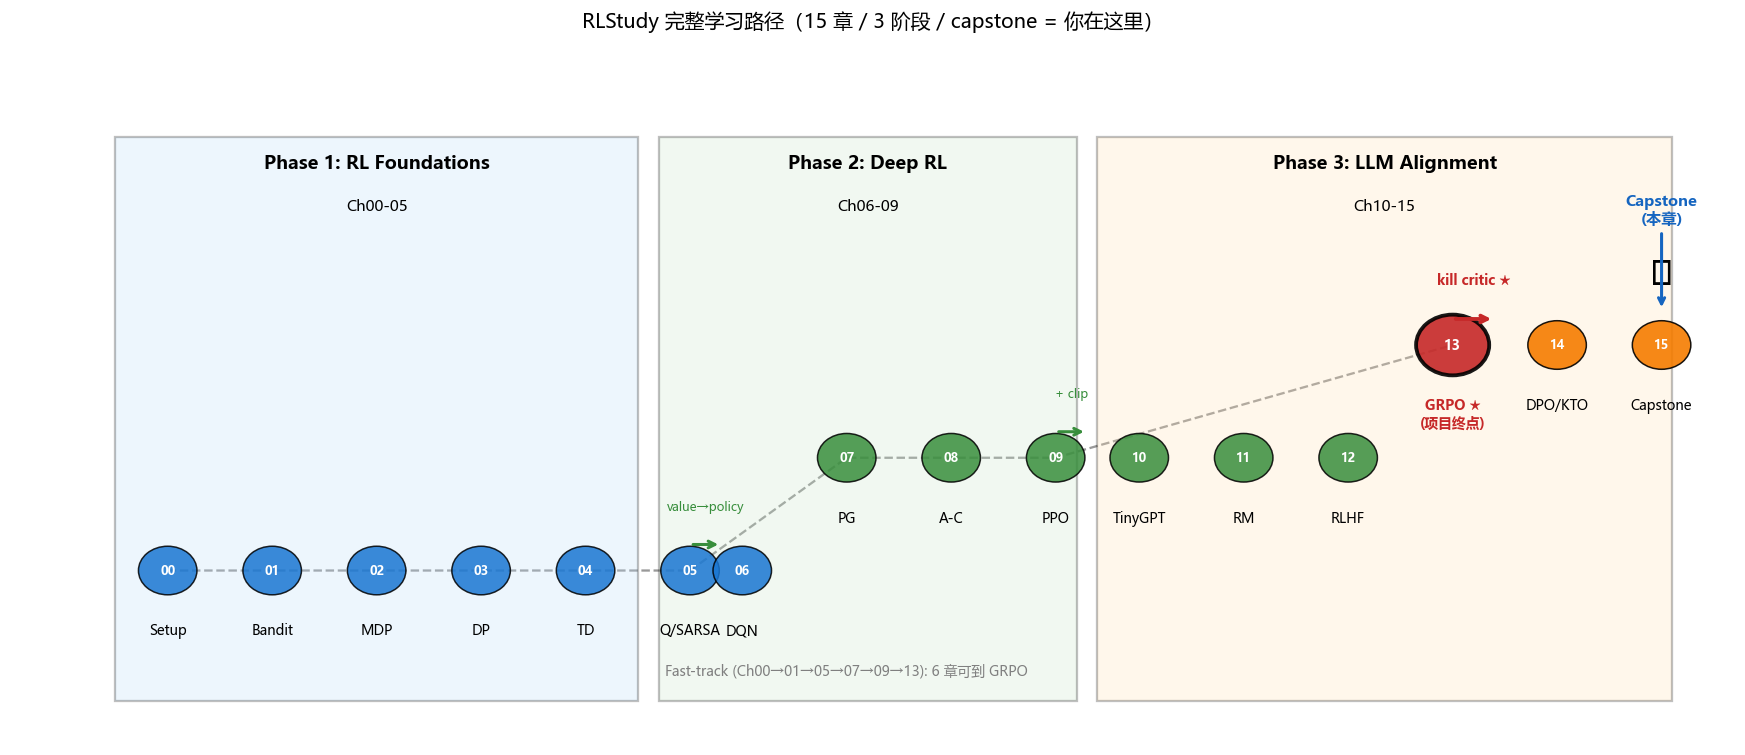

完整学习路径图已保存到 assets/ch15_full_learning_path.png


In [12]:
# 15.6.5 最终可视化：完整学习路径图（含 capstone 定位）
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(-0.5, 16)
ax.set_ylim(-2, 6)
ax.axis('off')

# 三个阶段大背景
phases = [
    (0.5, 5.0, '#bbdefb', 'Phase 1: RL Foundations', 'Ch00-05'),
    (5.7, 4.0, '#c8e6c9', 'Phase 2: Deep RL', 'Ch06-09'),
    (9.9, 5.5, '#ffe0b2', 'Phase 3: LLM Alignment', 'Ch10-15'),
]
for x, w, color, name, sub in phases:
    ax.add_patch(plt.Rectangle((x, -1.5), w, 6.5, facecolor=color,
                                edgecolor='black', alpha=0.25, linewidth=1.5))
    ax.text(x + w/2, 4.7, name, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(x + w/2, 4.2, sub, ha='center', va='center', fontsize=10, style='italic')

# 章节（按算法演化分两层）
chs_lower = [
    (1.0, 'Ch00', 'Setup'),    (2.0, 'Ch01', 'Bandit'),
    (3.0, 'Ch02', 'MDP'),      (4.0, 'Ch03', 'DP'),
    (5.0, 'Ch04', 'TD'),       (6.0, 'Ch05', 'Q/SARSA'),
    (6.5, 'Ch06', 'DQN'),
]
chs_upper = [
    (7.5, 'Ch07', 'PG'),       (8.5, 'Ch08', 'A-C'),
    (9.5, 'Ch09', 'PPO'),
    (10.3, 'Ch10', 'TinyGPT'), (11.3, 'Ch11', 'RM'),
    (12.3, 'Ch12', 'RLHF'),
]
chs_grpo = [
    (13.3, 'Ch13', 'GRPO ★', True),     # 终点
    (14.3, 'Ch14', 'DPO/KTO', False),
    (15.3, 'Ch15', 'Capstone', False),  # 本章节
]

for x, ch, name in chs_lower:
    circ = plt.Circle((x, 0), 0.28, facecolor='#1976d2', edgecolor='black', alpha=0.85)
    ax.add_patch(circ)
    ax.text(x, 0, ch[-2:], ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(x, -0.6, name, ha='center', va='top', fontsize=9)

for x, ch, name in chs_upper:
    circ = plt.Circle((x, 1.3), 0.28, facecolor='#388e3c', edgecolor='black', alpha=0.85)
    ax.add_patch(circ)
    ax.text(x, 1.3, ch[-2:], ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(x, 0.7, name, ha='center', va='top', fontsize=9)

for x, ch, name, is_grpo in chs_grpo:
    color = '#c62828' if is_grpo else '#f57c00'
    radius = 0.35 if is_grpo else 0.28
    circ = plt.Circle((x, 2.6), radius, facecolor=color, edgecolor='black',
                       linewidth=2.5 if is_grpo else 1.0, alpha=0.9)
    ax.add_patch(circ)
    ax.text(x, 2.6, ch[-2:], ha='center', va='center', fontsize=9 if is_grpo else 8,
            color='white', fontweight='bold')
    label = name + ('\n(项目终点)' if is_grpo else '')
    ax.text(x, 2.0, label, ha='center', va='top', fontsize=9,
            color='#c62828' if is_grpo else 'black', fontweight='bold' if is_grpo else 'normal')

# Capstone 装饰：王冠
ax.text(15.3, 3.4, '👑', ha='center', va='center', fontsize=22)
ax.annotate('Capstone\n(本章)', xy=(15.3, 3.0), xytext=(15.3, 4.0),
            ha='center', fontsize=10, fontweight='bold', color='#1565c0',
            arrowprops=dict(arrowstyle='->', color='#1565c0', lw=2))

# Fast-track 路径标注（虚线）
fast_track = [(1.0, 0), (2.0, 0), (6.0, 0), (7.5, 1.3), (9.5, 1.3), (13.3, 2.6)]
xs = [p[0] for p in fast_track]
ys = [p[1] for p in fast_track]
ax.plot(xs, ys, 'k--', alpha=0.4, linewidth=1.5, zorder=0)
ax.text(7.5, -1.2, 'Fast-track (Ch00→01→05→07→09→13): 6 章可到 GRPO',
        ha='center', fontsize=9, style='italic', color='gray')

# 三个关键跳变箭头
ax.annotate('', xy=(6.3, 0.3), xytext=(6.0, 0.3),
            arrowprops=dict(arrowstyle='->', color='#388e3c', lw=2))
ax.text(6.15, 0.7, 'value→policy', fontsize=8, color='#388e3c', ha='center')

ax.annotate('', xy=(9.8, 1.6), xytext=(9.5, 1.6),
            arrowprops=dict(arrowstyle='->', color='#388e3c', lw=2))
ax.text(9.65, 2.0, '+ clip', fontsize=8, color='#388e3c', ha='center')

ax.annotate('', xy=(13.7, 2.9), xytext=(13.3, 2.9),
            arrowprops=dict(arrowstyle='->', color='#c62828', lw=2.5))
ax.text(13.5, 3.3, 'kill critic ★', fontsize=9, color='#c62828',
        ha='center', fontweight='bold')

ax.set_title('RLStudy 完整学习路径（15 章 / 3 阶段 / capstone = 你在这里）',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(str(ROOT / 'assets' / 'ch15_full_learning_path.png'), dpi=110, bbox_inches='tight')
plt.show()
print("完整学习路径图已保存到 assets/ch15_full_learning_path.png")


### 15.6.6 致学习者

走到这里的你已经完成了：
- **19 章** 的从零推导（+ Ch05b PyTorch 速成）
- **11 套** 自研算法实现
- **157 个** 单元测试
- 一个**端到端可跑的 reasoning RL demo**（即使是在 CPU 上的玩具版本）

这些工作量大致等价于一门研究生级别的 RL 专题课 + 一个完整的开源项目贡献。

**接下来怎么走**，取决于你的目标：

| 目标 | 下一步 |
|---|---|
| 想做研究 | 读 DeepSeek-R1 + 最近 3 个月 arXiv，复现一个改进 |
| 想做工程 | 申请 GPU，按 §15.3 配方在 1.5B 模型上跑一遍 GSM8K |
| 想做产品 | 学 vLLM / TensorRT-LLM 部署，把训好的模型服务化 |
| 想转方向 | RL → Diffusion（图像）/ World Model（Sora style）/ Agent |

不管哪条路，**RLStudy 给你的底子都不会浪费**——因为所有现代 AI 系统
（不管是 LLM、Diffusion、还是 World Model）都在用 RL 做对齐和优化。

---

**这就是 RLStudy 的终点。**

> *"We have not succeeded in answering all our problems—indeed, we sometimes feel
> we have not completely answered any of them. The answers we have found have only
> served to raise a whole new set of questions. In some ways, we feel we are as
> confused as ever, but we believe we are confused on a higher level and about
> more important things."*
>
> — 改编自 Alfred North Whitehead

Happy reinforcing.
